In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
#Load Dataset
df = pd.read_csv('D:/downloads 2 imp/2ND TERM 3RD YEAR/Intelligent Programming/MAIN PROJECT/data/heart.csv')
#Check for Missing and Duplicated Values
print(f"Missing values:\n{df.isnull().sum()}")
print(f"Number of duplicated rows: {df.duplicated().sum()}")
#Handle Missing Values: Filling numerical with median and categorical with mode
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     1
thalach     0
exang       0
oldpeak     2
slope       0
ca          0
thal        0
target      0
dtype: int64
Number of duplicated rows: 720


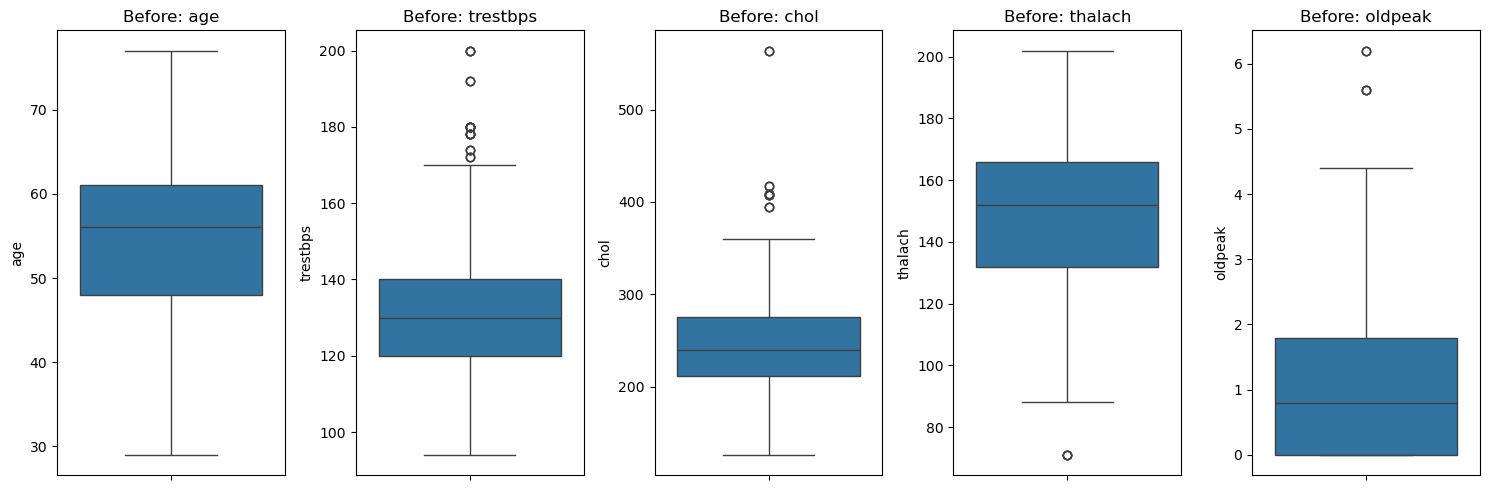

In [3]:
#Define feature types
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
#Handle Outliers - Boxplot before and after for all numerical features
#Visualize Before Outlier Handling
plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 5, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Before: {col}')
plt.tight_layout()

In [4]:
#Outlier handling loop using IQR Method
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

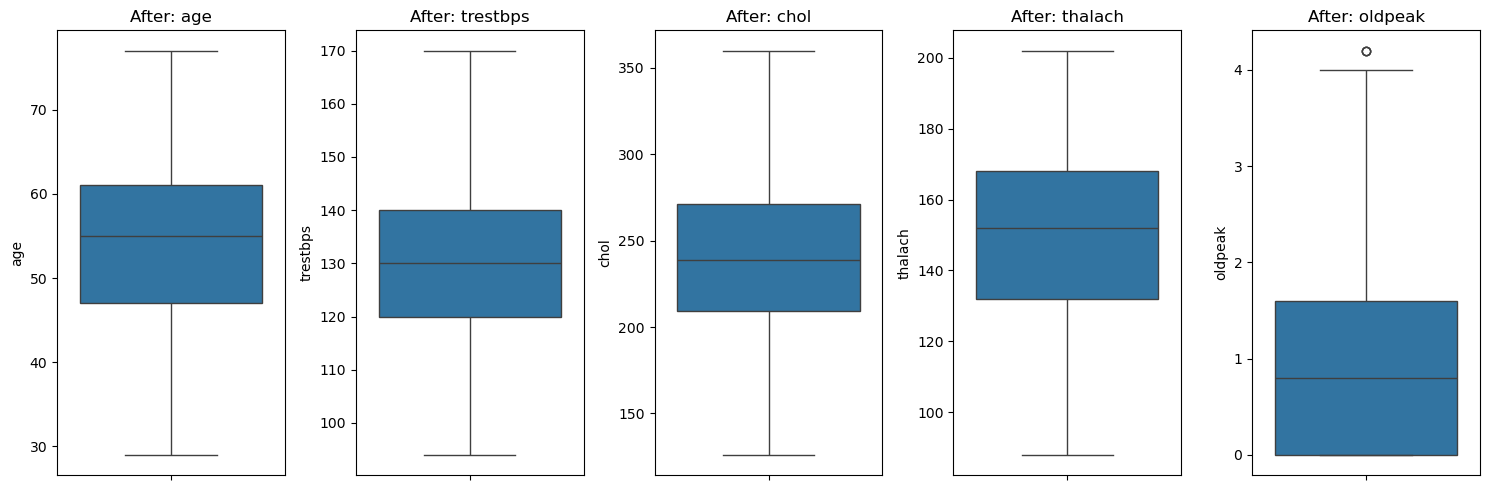

In [5]:
#Visualize After Outlier Handling
plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 5, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'After: {col}')
plt.tight_layout()

In [6]:
#Normalize Data: Scale numerical features using MinMaxScaler
#This step scales values to a range between 0 and 1.
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

#Encode Categorical Variables: Convert using One-Hot Encoding
#This converts categorical values into numerical binary representations.
df_encoded = pd.get_dummies(df, columns=cat_cols)

C:\Users\abdul\AppData\Local\Temp\ipykernel_9272\2494345857.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_plot_data.values, y=importance_plot_data.index, palette='plasma')


Final columns in 'cleaned_data.csv': ['target', 'oldpeak', 'exang', 'thalach', 'cp', 'ca', 'thal', 'slope', 'sex', 'age', 'restecg', 'chol', 'trestbps']


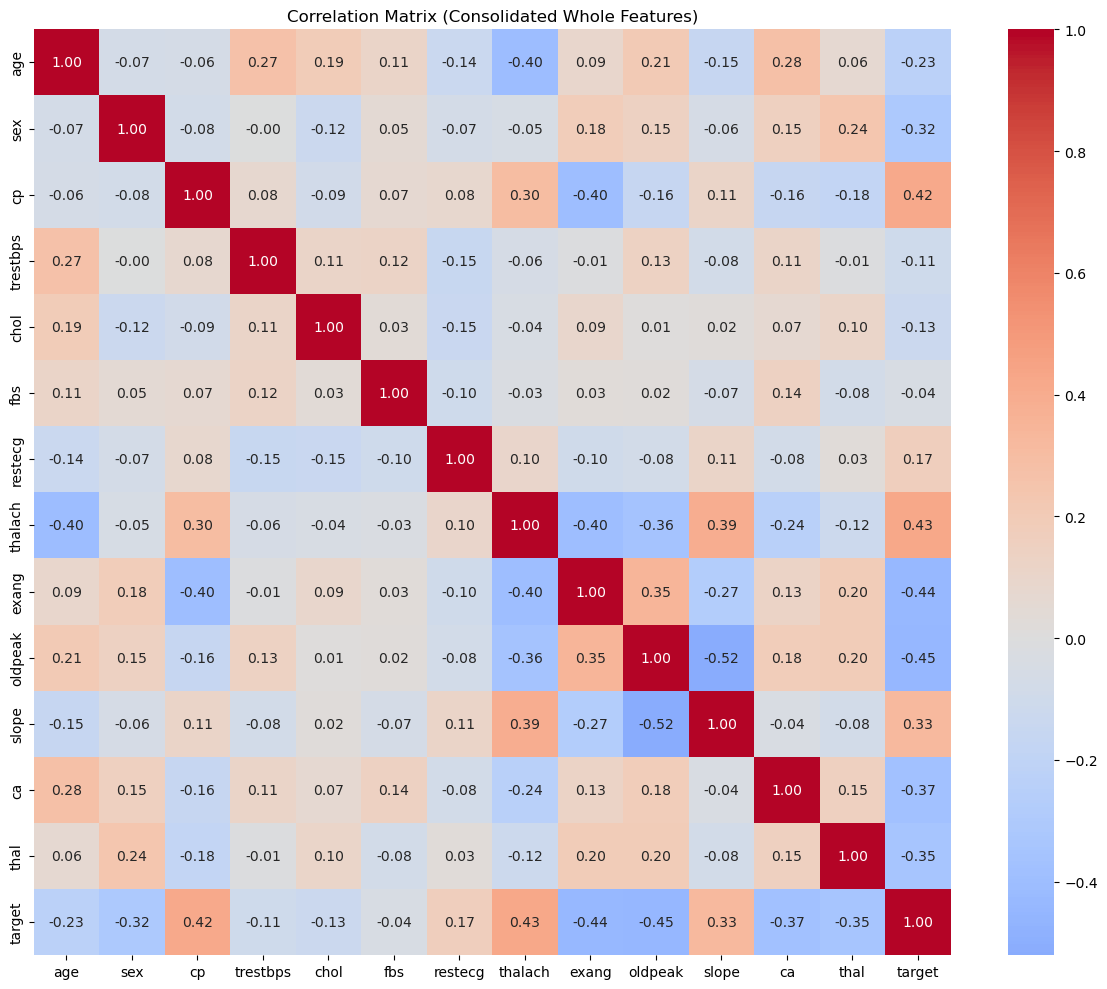

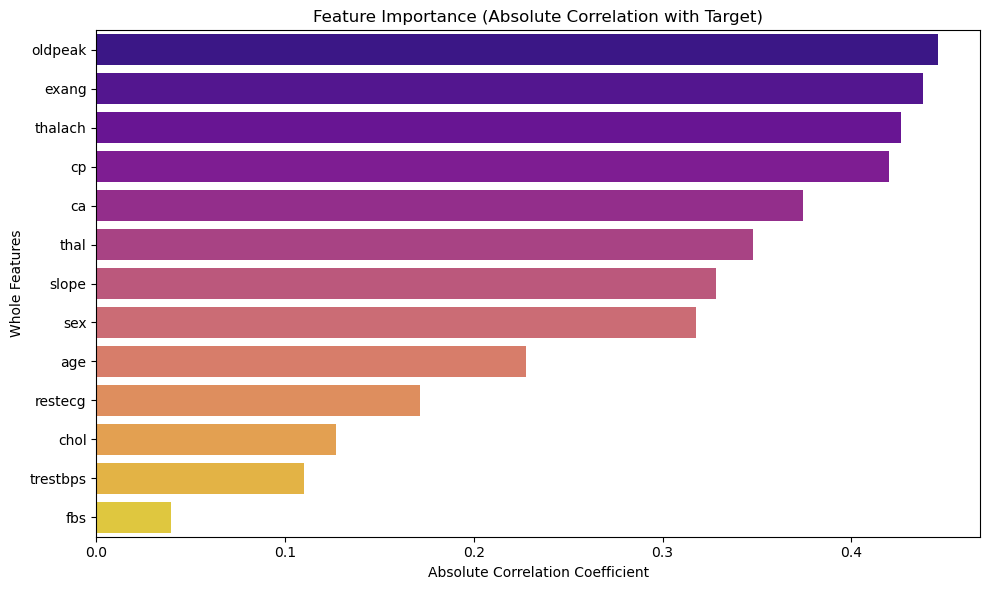

In [7]:
#FEATURE SELECTION: Consolidated Correlation Analysis
#To avoid spreading features into dummy variables like 'ca_1', 'ca_2', 
#we calculate correlation on the whole categorical features directly.
correlation_matrix = df.corr()

#A)Correlation Heatmap (Whole Features)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Consolidated Whole Features)')
plt.tight_layout()

#B)Feature Importance Plot (Absolute Correlation of Target with Whole Feature)
target_correlations = correlation_matrix['target'].abs().sort_values(ascending=False)
importance_plot_data = target_correlations.drop('target') 

plt.figure(figsize=(10, 6))
sns.barplot(x=importance_plot_data.values, y=importance_plot_data.index, palette='plasma')
plt.title('Feature Importance (Absolute Correlation with Target)')
plt.xlabel('Absolute Correlation Coefficient')
plt.ylabel('Whole Features')
plt.tight_layout()

#Final Feature Selection and Saving (Including the Target column)
threshold = 0.1
#Keeping features above the 0.1 correlation threshold
selected_features = target_correlations[target_correlations >= threshold].index.tolist()

df_final = df[selected_features]
df_final.to_csv('D:/downloads 2 imp/2ND TERM 3RD YEAR/Intelligent Programming/MAIN PROJECT/DATA Visiualization/cleaned_data.csv', index=False)
print(f"Final columns in 'cleaned_data.csv': {df_final.columns.tolist()}")